In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import plotly.graph_objects as go
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.proportion import proportions_ztest


In [2]:
df_analysis = pd.read_excel("C:/Users/mickt/Downloads/get_around_delay_analysis(1).xlsx")
df_machine_learning = pd.read_csv("C:/Users/mickt/Downloads/get_around_pricing_project(1).csv")

In [235]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


In [236]:
df_analysis.head()

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [101]:
df_analysis.shape

(21310, 7)

In [102]:
df_analysis.isna().sum()

rental_id                                         0
car_id                                            0
checkin_type                                      0
state                                             0
delay_at_checkout_in_minutes                   4964
previous_ended_rental_id                      19469
time_delta_with_previous_rental_in_minutes    19469
dtype: int64

In [4]:
df_clean = df_analysis.copy()

In [5]:
df_delay = df_clean[df_clean["state"] == "ended"]
df_delay = df_delay[df_delay["delay_at_checkout_in_minutes"].notna()]

## Threshold: how long should the minimum delay be?

## scope: should we enable the feature for all cars?, only Connect cars?

In [195]:
df_clean["state"].value_counts()

state
ended       18045
canceled     3265
Name: count, dtype: int64

In [228]:
df_clean["checkin_type"].value_counts()

checkin_type
mobile     17003
connect     4307
Name: count, dtype: int64

In [ ]:
df_car_type = df_delay[
    (df_delay["delay_at_checkout_in_minutes"] >= -1440) &   # - 1 day early
    (df_delay["delay_at_checkout_in_minutes"] <= 4320)      # + 3 days late
]
df_car_type_delay = df_delay[df_delay["delay_at_checkout_in_minutes"] > 0]
df_car_type_delay.groupby(df_car_type_delay["checkin_type"])["delay_at_checkout_in_minutes"].mean()

checkin_type
connect     80.109664
mobile     170.989637
Name: delay_at_checkout_in_minutes, dtype: float64

In [ ]:

df_delay_analysis = df_delay.copy()
df_delay_analysis["problem_case"] = (df_delay_analysis["delay_at_checkout_in_minutes"] 
                                     > df_delay_analysis["time_delta_with_previous_rental_in_minutes"])

In [ ]:
import plotly.graph_objects as go

checkin_types = df_delay_analysis["checkin_type"].unique().tolist()  # e.g., ['connect', 'mobile']
conflict_states = ['Conflict', 'No Conflict']

# Step 2: create a list of all nodes
nodes = checkin_types + conflict_states  # ['connect', 'mobile', 'Conflict', 'No Conflict']
node_map = {label: i for i, label in enumerate(nodes)}
# {'connect': 0, 'mobile': 1, 'Conflict': 2, 'No Conflict': 3}

df_links = df_delay_analysis.copy()
df_links["conflict_label"] = df_links["problem_case"].apply(lambda x: "Conflict" if x else "No Conflict")

link_counts = df_links.groupby(["checkin_type", "conflict_label"]).size().reset_index(name="count")


In [8]:
link_counts["source"] = link_counts["checkin_type"].map(node_map)
link_counts["target"] = link_counts["conflict_label"].map(node_map)

In [9]:
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=link_counts["source"],
        target=link_counts["target"],
        value=link_counts["count"]
    )
)])

fig.update_layout(title_text="Checkin Type vs Conflict", font_size=12)
fig.show()

#### Late returns in mobile check-ins tend to be significantly longer than those in connect rentals.
#### On average, mobile rentals that are returned late are delayed by about 171 minutes, compared to 80 minutes for connect rentals.

### How often are drivers late for the next check-in? How does it impact the next driver?

In [196]:
df_delay["delay_at_checkout_in_minutes"].describe()

count    16345.000000
mean        60.773876
std        993.173222
min     -22433.000000
25%        -36.000000
50%          9.000000
75%         67.000000
max      71084.000000
Name: delay_at_checkout_in_minutes, dtype: float64

In [ ]:
# number of outliers in delayed rentals
df_delay[df_delay["delay_at_checkout_in_minutes"] < -1000] # beyond 16 hours early
df_delay[df_delay["delay_at_checkout_in_minutes"] > 10000] # beyond 7 days late

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
153,540733,393558,mobile,ended,15422.0,NaN,NaN
1021,532240,379042,mobile,ended,71084.0,NaN,NaN
1038,534699,270195,mobile,ended,23126.0,NaN,NaN
1427,546459,297511,mobile,ended,12968.0,NaN,NaN
1787,549980,402829,mobile,ended,64059.0,NaN,NaN
5257,556557,413591,mobile,ended,22618.0,NaN,NaN
9080,554989,366198,mobile,ended,14408.0,NaN,NaN
13446,539642,396000,mobile,ended,10323.0,NaN,NaN
13776,537546,408750,mobile,ended,37382.0,NaN,NaN
15485,552196,278701,mobile,ended,13463.0,NaN,NaN


In [59]:
df_delay = df_delay[
    (df_delay["delay_at_checkout_in_minutes"] >= -1440) &   # - 1 day early
    (df_delay["delay_at_checkout_in_minutes"] <= 4320)      # + 3 days late
]
late = df_delay[df_delay["delay_at_checkout_in_minutes"] > 0]

In [68]:
delay_time = late["delay_at_checkout_in_minutes"]

mean_delay = delay_time.mean()
std_delay = delay_time.std()
n = len(delay_time)
se = std_delay / np.sqrt(n)

ci_low, ci_high = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean_delay,
    scale=se
)

gap_time = early["delay_at_checkout_in_minutes"]
mean_gap = gap_time.mean()
std_gap = gap_time.std()
n_gap = len(gap_time)
se_gap = std_gap / np.sqrt(n_gap)

ci_low_gap, ci_high_gap = stats.t.interval(
    0.95,
    df=n_gap-1,
    loc=mean_gap,
    scale=se_gap
)

print(f"Mean delay: {mean_delay:.2f} minutes")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
late['delay_at_checkout_in_minutes'].describe()


Mean delay: 156.84 minutes
95% CI: [149.55, 164.14]


count    9372.000000
mean      156.841763
std       360.306655
min         1.000000
25%        19.000000
50%        53.000000
75%       130.000000
max      4274.000000
Name: delay_at_checkout_in_minutes, dtype: float64

C:\Users\mickt\AppData\Local\Temp\ipykernel_17852\2416788873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  late_hr = late["delay_hours"] = late["delay_at_checkout_in_minutes"] / 60


<Axes: xlabel='delay_at_checkout_in_minutes', ylabel='Count'>

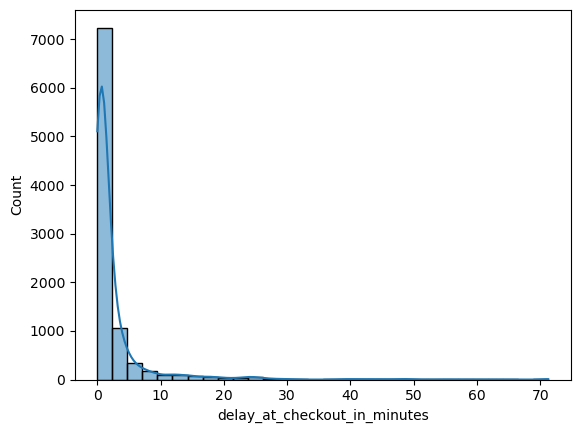

In [70]:
late_hr = late["delay_hours"] = late["delay_at_checkout_in_minutes"] / 60
sns.histplot(late_hr, bins=30, kde=True)

In [66]:
late_hr.describe()

count    9372.000000
mean        2.614029
std         6.005111
min         0.016667
25%         0.316667
50%         0.883333
75%         2.166667
max        71.233333
Name: delay_at_checkout_in_minutes, dtype: float64

#### The distribution of late returns is positively skewed: while the average delay is about 2.6, the median delay is about ~53 minutes.
#### This indicates that most delays are  relatively short, but a small number of extreme delays(up to ~71 hours) increase the mean.

In [67]:
late_rate = len(late) / len(df_delay)
print(f'Drivers are late {late_rate:.2%} of the time')

Drivers are late 57.59% of the time


#### How does it impact the next driver ?

In [ ]:
#filtering out extreme outliers for the problem case analysis, the dataframe is the same as df_delay_analysis but with outliers removed
df_problem = df_clean.copy()
df_problem = df_problem[(df_problem["delay_at_checkout_in_minutes"] >= -1440) & (df_problem["delay_at_checkout_in_minutes"] <= 4320)]
df_problem["problem_case"] = (df_problem["delay_at_checkout_in_minutes"] > df_problem["time_delta_with_previous_rental_in_minutes"])

In [26]:
df_problem = df_problem[
    df_problem["time_delta_with_previous_rental_in_minutes"].notna()
]

In [27]:
df_problem['problem_case'].value_counts()

problem_case
False    1242
True      268
Name: count, dtype: int64

#### Only 1510 case remains where a rental was made beforehand and within reasonable boundaries of timelapses of + 3 days and - 1 day to return the car .

In [52]:
df_problem.groupby("state")["problem_case"].sum()

state
ended    268
Name: problem_case, dtype: int64

In [54]:
df_problem["problem_case"].groupby("state").sum()

KeyError: 'state'

In [242]:
df_problem["time_delta_with_previous_rental_in_minutes"].sort_values().value_counts()

time_delta_with_previous_rental_in_minutes
0.0      226
60.0     145
120.0    117
720.0    113
30.0     108
90.0      72
180.0     70
660.0     59
150.0     57
240.0     56
600.0     54
690.0     49
630.0     41
570.0     38
210.0     35
300.0     33
540.0     33
270.0     32
360.0     32
480.0     31
420.0     30
510.0     30
330.0     21
450.0     17
390.0     11
Name: count, dtype: int64

In [243]:
df_problem["time_delta_with_previous_rental_in_minutes"].describe()

count    1510.000000
mean      276.774834
std       254.729412
min         0.000000
25%        60.000000
50%       180.000000
75%       540.000000
max       720.000000
Name: time_delta_with_previous_rental_in_minutes, dtype: float64

### How many problematic cases will it solve depending on the chosen threshold and scope?

In [272]:
threshold = [60,30,20] 
for i in threshold:
    df_threshold = df_problem[
    df_problem["time_delta_with_previous_rental_in_minutes"] < i]
    print(f"Threshold: {i} minutes")
    print(df_threshold["problem_case"].value_counts())

Threshold: 60 minutes
problem_case
True     176
False    158
Name: count, dtype: int64
Threshold: 30 minutes
problem_case
True     136
False     90
Name: count, dtype: int64
Threshold: 20 minutes
problem_case
True     136
False     90
Name: count, dtype: int64


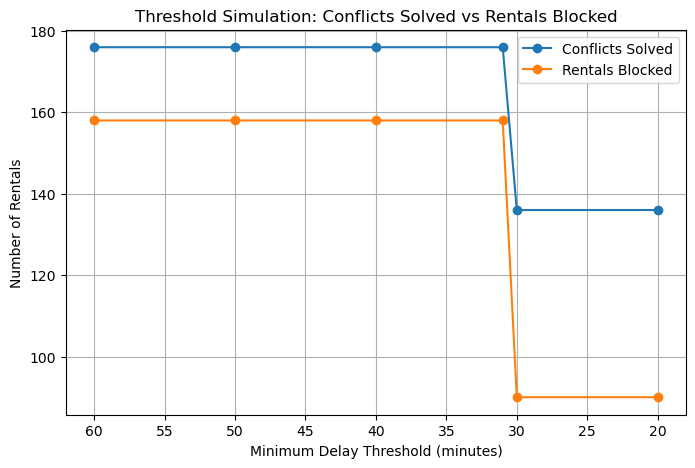

In [273]:
thresholds = [60, 50, 40, 31, 30, 20]

results = []
for t in thresholds:
    df_thresh = df_problem[df_problem["time_delta_with_previous_rental_in_minutes"] < t]
    conflicts = df_thresh["problem_case"].sum()
    blocked = len(df_thresh) - conflicts
    results.append({"threshold": t, "conflicts_solved": conflicts, "rentals_blocked": blocked})

df_results = pd.DataFrame(results)

# Plot
plt.figure(figsize=(8,5))
plt.plot(df_results["threshold"], df_results["conflicts_solved"], marker='o', label="Conflicts Solved")
plt.plot(df_results["threshold"], df_results["rentals_blocked"], marker='o', label="Rentals Blocked")
plt.xlabel("Minimum Delay Threshold (minutes)")
plt.ylabel("Number of Rentals")
plt.title("Threshold Simulation: Conflicts Solved vs Rentals Blocked")
plt.gca().invert_xaxis()  
plt.legend()
plt.grid(True)
plt.show()

#### The optimal threshold appears to lie between 20 and 30 minutes.
#### However, due to the distribution and granularity of the available data, a more precise cutoff cannot be determined.
#### Additionally, because the dataset does not provide information about the geographical context of rentals, the results may be subject to sampling bias.
#### Rental behavior may differ between urban and rural environments or across regions, which could affect the applicability of the threshold in different contexts.

### How many rentals would be affected by the feature depending on the threshold and scope we choose?

In [248]:
print(f'At a 20-minute threshold, we can solve {df_results[df_results["threshold"] == 20]["conflicts_solved"].values[0]} conflicts while blocking {df_results[df_results["threshold"] == 20]["rentals_blocked"].values[0]} rentals.')
print(f'At a 30-minute threshold, we can solve {df_results[df_results["threshold"] == 30]["conflicts_solved"].values[0]} conflicts while blocking {df_results[df_results["threshold"] == 30]["rentals_blocked"].values[0]} rentals.')
print(f'At a 31-minute threshold, we can solve {df_results[df_results["threshold"] == 31]["conflicts_solved"].values[0]} conflicts while blocking {df_results[df_results["threshold"] == 31]["rentals_blocked"].values[0]} rentals.')
print(f'At a 40-minute threshold, we can solve {df_results[df_results["threshold"] == 40]["conflicts_solved"].values[0]} conflicts while blocking {df_results[df_results["threshold"] == 40]["rentals_blocked"].values[0]} rentals.')
print(f'At a 50-minute threshold, we can solve {df_results[df_results["threshold"] == 50]["conflicts_solved"].values[0]} conflicts while blocking {df_results[df_results["threshold"] == 50]["rentals_blocked"].values[0]} rentals.')
print(f'At a 60-minute threshold, we can solve {df_results[df_results["threshold"] == 60]["conflicts_solved"].values[0]} conflicts while blocking {df_results[df_results["threshold"] == 60]["rentals_blocked"].values[0]} rentals.')


At a 20-minute threshold, we can solve 136 conflicts while blocking 90 rentals.
At a 30-minute threshold, we can solve 136 conflicts while blocking 90 rentals.
At a 31-minute threshold, we can solve 176 conflicts while blocking 158 rentals.
At a 40-minute threshold, we can solve 176 conflicts while blocking 158 rentals.
At a 50-minute threshold, we can solve 176 conflicts while blocking 158 rentals.
At a 60-minute threshold, we can solve 176 conflicts while blocking 158 rentals.


In [283]:
print(f'Number of unique car IDs: {df_clean["car_id"].nunique()}')
# Getaround has 20000 cars, but only 8143 unique car IDs in the dataset.
print(f'Proportion of unique car IDs: {8143/20000*100:.2f}%')

Number of unique car IDs: 8143
Proportion of unique car IDs: 40.72%


#### The dataset contains 8,143 unique cars, representing roughly 40% of the ~20,000 cars available on the platform.
#### This large coverage increases confidence in the statistical estimates. 
#### However, since no geographic information is available, the dataset may still contain sampling bias, and the results may not fully generalize to all markets.

### Which share of our owner’s revenue would potentially be affected by the feature?

In [250]:
df_results["conflicts_solved"].values[0] / df_results["rentals_blocked"].values[0]

np.float64(1.1139240506329113)

In [253]:
df_problem['problem_case'].value_counts()

problem_case
False    1242
True      268
Name: count, dtype: int64

In [254]:
conflict_rate = df_problem["problem_case"].mean()
print(conflict_rate)

0.17748344370860927


In [266]:
conflicts = df_problem["problem_case"].sum()
n = len(df_problem)
p = conflicts / n
ci_low, ci_high = proportion_confint(conflicts, n, method="wilson")
print(f"Conflict rate: {p:.3f}")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Sample size: {n}")

se = np.sqrt(p * (1 - p) / n)
print(f"Standard error: {se:.4f}")

count = conflicts
nobs = n
value = 0.10  # hypothesis

stat, pval = proportions_ztest(count, nobs, value)

print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval:.2e}")

Conflict rate: 0.177
95% CI: [0.159, 0.198]
Sample size: 1510
Standard error: 0.0098
Z-statistic: 7.880
P-value: 3.26e-15


#### Among the 1510 that occured after a previous rental, 17.77% resulted in conflicts(i.e., the previous owner was late)
#### The 95% confidence interval is 15.9%-19.8%, showing the estimate is precise.
#### The extremely small P-value confirms the conflict rate is significantly higher than 10% (or any reasonnable baseline).
#### Therefore the minimum delay feature could impact up to 17.7% of sequential rentals, which is  the subset of rentals where the feature applies.

In [ ]:
total_rentals = len(df_clean)
for i in thresholds:
    blocked_rentals = len(df_problem[df_problem["time_delta_with_previous_rental_in_minutes"] < i])
    revenue_impact = blocked_rentals / total_rentals
    print(f"Potentially affected rentals for {i} minutes of all rentals: {blocked_rentals} / {total_rentals} ≈ {revenue_impact:.2%}")

Potentially affected rentals for 60 minutes of all rentals: 334 / 21310 ≈ 1.57%
Potentially affected rentals for 50 minutes of all rentals: 334 / 21310 ≈ 1.57%
Potentially affected rentals for 40 minutes of all rentals: 334 / 21310 ≈ 1.57%
Potentially affected rentals for 31 minutes of all rentals: 334 / 21310 ≈ 1.57%
Potentially affected rentals for 30 minutes of all rentals: 226 / 21310 ≈ 1.06%
Potentially affected rentals for 20 minutes of all rentals: 226 / 21310 ≈ 1.06%
